In [1]:
import sys
import os

sys.path.append('../src/scripts')
sys.path.append('../src/classes')
from simulation import Simulation
from config import get_simulation_number
from data_scraping_in_results import scraper

In [2]:
mobility_file_path = '../src/sumo/csv/train_single.csv'
edge_file_path = '../src/inputs/train/edge_servers.json'
vehicle_file_path = '../src/inputs/train/vehicles_single.json'


In [3]:
_proposed="proposed"
_local= "local_only"
_offload = "offload_only"
_random = "random"
algorithms = [_proposed,_local,_offload,_random]
simulation_number = 37
report_paths = {}

for a in algorithms:
    report_paths[a] = ('../results/reports/'+str(simulation_number)+'_report_'+a+'_test.csv')
q_table_path = '../results/q_table/'+str(simulation_number)+'_q_table_proposed'
num_of_cars=20
# should_update_q_table = False
print(report_paths)

{'proposed': '../results/reports/37_report_proposed_test.csv', 'local_only': '../results/reports/37_report_local_only_test.csv', 'offload_only': '../results/reports/37_report_offload_only_test.csv', 'random': '../results/reports/37_report_random_test.csv'}


In [4]:
scrapers={}
for a in algorithms:
    scrapers[a] = scraper(report_paths[a],num_of_cars)

---------------------------------------------
../results/reports/37_report_proposed_test.csv
Header --->
   vehicle_id  task_id  execution_location     size    distance  \
0           1        1                   0  3000000  193.826094   
1           1        5                   0  7000000  193.625845   
2           1        4                   1  2000000  193.716216   
3           1        7                   0  9000000  193.385640   
4           1        2                   1  3000000  193.816105   

   transfer_rate  execution_cycles  start_time  end_time  release_time  \
0       0.000000        5000000000           1      5001             1   
1       0.000000        4000000000        5001      9001           401   
2  954127.749293        7000000000       14309     15709           301   
3       0.000000        8000000000        9001     17001           601   
4  952175.240589       10000000000       23909     25909           101   

   response_time  transmission_time  execution_

In [5]:
for a in algorithms:
    print("=========================================")
    print(a,"------->")
    scrapers[a].calc_average_all()



proposed ------->
The overall average of our results:
response_time        457009.083208
transmission_time      2563.575891
execution_time         2700.544090
execution_energy          0.186989
transfer_energy           0.769072
total_energy              0.956061
dtype: float64
The overall average of simulation specific parameters:
execution_location    6.896811e-01
size                  5.940994e+06
distance              1.494513e+02
transfer_rate         1.574306e+07
execution_cycles      6.023171e+09
dtype: float64
local_only ------->
The overall average of our results:
response_time        489599.940030
transmission_time         0.000000
execution_time         5973.313343
execution_energy          0.597331
transfer_energy           0.000000
total_energy              0.597331
dtype: float64
The overall average of simulation specific parameters:
execution_location    0.000000e+00
size                  6.046777e+06
distance              1.542496e+02
transfer_rate         0.000000e+00


In [6]:
for a in algorithms:
    print("=========================================")
    print(a,"----------AVERAGED----->")
    scrapers[a].calc_average_for_each_car()

proposed ----------AVERAGED----->
            response_time  transmission_time  execution_time  \
vehicle_id                                                     
1           439834.771134        2358.934021     2832.989691   
2           539780.548544        3199.842233     2164.805825   
3           520177.119231        2844.178846     2785.769231   
4           326275.595113        1485.080279     2567.539267   
5           499917.415822        1816.068966     2823.935091   
6           363314.106768        1339.831268     1946.425167   
7           437214.812950        4584.100719     3098.321343   
8           450644.183246        1160.034031     3256.544503   
9           521511.956723        2818.962906     2417.928903   
10          491637.270732        2571.556098     3115.121951   
11          564919.633397        1519.309021     2733.973129   
12          366906.670051        1209.800338     2611.167513   
13          523401.276944        2472.384720     2292.769441   
14    

            response_time  transmission_time  execution_time  \
vehicle_id                                                     
1           479819.512195                0.0     6085.365854   
2           502454.819277                0.0     6018.072289   
3           487723.952096                0.0     5964.071856   
4           477656.329114                0.0     6316.455696   
5           496391.428571                0.0     5708.571429   
6           494093.373494                0.0     6018.072289   
7           490918.965517                0.0     5718.390805   
8           488313.414634                0.0     6073.170732   
9           503868.789809                0.0     6350.318471   
10          499762.820513                0.0     6371.794872   
11          489391.428571                0.0     5702.857143   
12          494147.590361                0.0     5975.903614   
13          476397.727273                0.0     5642.045455   
14          482154.878049               

In [7]:
for a in algorithms:
    print("=========================================")
    print(a,"----TOTAL------->")
    scrapers[a].calc_sum_for_each_car()

proposed ----TOTAL------->
            response_time  transmission_time  execution_time  \
vehicle_id                                                     
1               213319864            1144083         1374000   
2               444779172            2636670         1783800   
3               270492102            1478973         1448600   
4               186955916             850951         1471200   
5               246459286             895322         1392200   
6               381116498            1405483         2041800   
7               182318577            1911570         1292000   
8               172146078             443133         1244000   
9               337418236            1823869         1564400   
10              201571281            1054338         1277200   
11              294323129             791560         1424400   
12              216841842             714992         1543200   
13              383653136            1812258         1680600   
14           

proposed -------AVERAGE----->
          response_time  transmission_time  execution_time  execution_energy  \
end_time                                                                       
457               456.0               56.0           400.0               0.0   
1309              908.0              308.0           600.0               0.0   
2057             1956.0              112.0          1600.0               0.0   
2739             2638.0             1238.0          1400.0               0.0   
2909             2708.0              552.0          1600.0               0.0   
...                 ...                ...             ...               ...   
999411         954210.0               33.0           800.0               0.0   
999537         958236.0             4587.0          1000.0               0.0   
999625         892624.0              151.0          1200.0               0.0   
999657         955356.0             4430.0          1600.0               0.0   
999767    

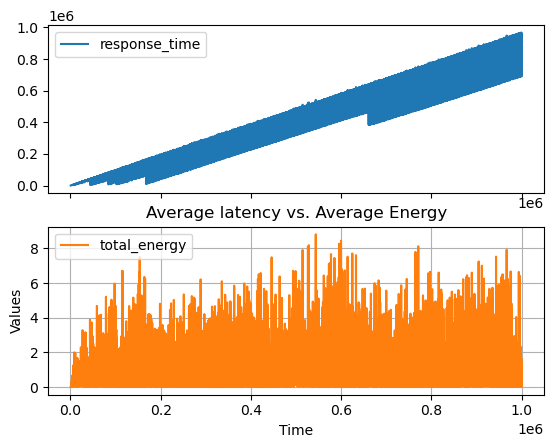

local_only -------AVERAGE----->
          response_time  transmission_time  execution_time  execution_energy  \
end_time                                                                       
2001        2000.000000                0.0     2000.000000          0.200000   
3001        3000.000000                0.0     3000.000000          0.300000   
4001        3975.000000                0.0     3500.000000          0.350000   
5001        5000.000000                0.0     5000.000000          0.500000   
6001        5966.666667                0.0     5333.333333          0.533333   
...                 ...                ...             ...               ...   
995001    978600.000000                0.0     5500.000000          0.550000   
996001    979600.000000                0.0     6666.666667          0.666667   
997001    980540.000000                0.0     6000.000000          0.600000   
998001    981533.333333                0.0     9333.333333          0.933333   
999001  

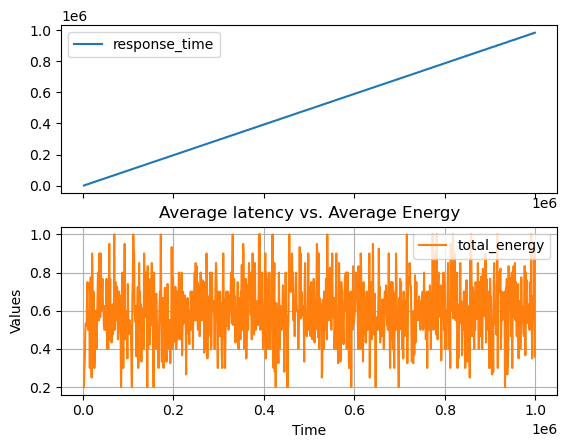

offload_only -------AVERAGE----->
          response_time  transmission_time  execution_time  execution_energy  \
end_time                                                                       
1229             1228.0              428.0           800.0               0.0   
1350             1149.0              349.0           800.0               0.0   
1720             1519.0              319.0          1200.0               0.0   
1829             1728.0              367.0           600.0               0.0   
1950             1849.0              698.0           600.0               0.0   
...                 ...                ...             ...               ...   
999350         971849.0             2571.0          1200.0               0.0   
999399         960798.0             2052.0           400.0               0.0   
999816         813415.0             3011.0          1200.0               0.0   
999913         974912.0             1650.0          1600.0               0.0   
999999

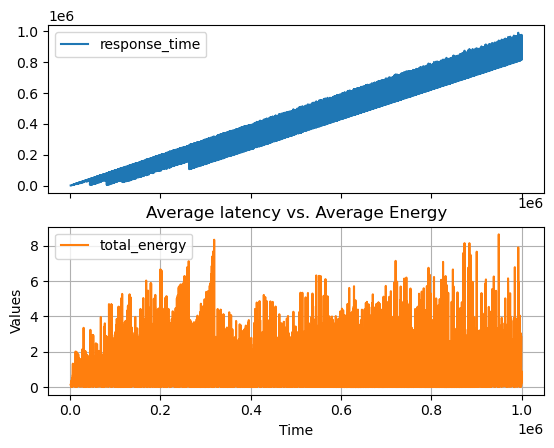

random -------AVERAGE----->
          response_time  transmission_time  execution_time  execution_energy  \
end_time                                                                       
1241              940.0              140.0           800.0               0.0   
1867             1666.0              866.0           800.0               0.0   
2080             2079.0              479.0          1600.0               0.0   
2101             2000.0                0.0          2000.0               0.2   
2201             2000.0                0.0          2000.0               0.2   
...                 ...                ...             ...               ...   
999267         856866.0             9115.0           800.0               0.0   
999280         932379.0             5231.0          1800.0               0.0   
999680         931579.0             4039.0           400.0               0.0   
999697         956296.0             2762.0          1600.0               0.0   
999807      

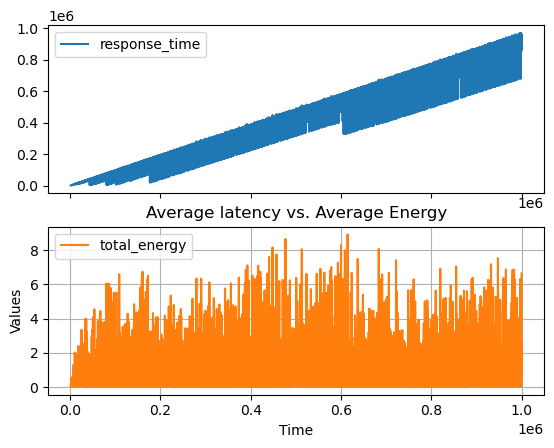

In [8]:
for a in algorithms:
    print("=========================================")
    print(a,"-------AVERAGE----->")
    scrapers[a].calc_average_for_each_end_time(plot=True)